# Experiment: Figure 2 `x(\hat{\theta})` Mapping

This notebook plots the theoretical encoding map from edge position $\hat{\theta}$ to latent decision variable $x$ using the model's existing `pos_to_evidence(...)` transform over the coding range.

In [1]:
from __future__ import annotations

import runpy
from pathlib import Path

_NOTEBOOK_SETUP = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    helper = candidate / "figures_code" / "notebook_setup.py"
    if helper.exists():
        _NOTEBOOK_SETUP = runpy.run_path(str(helper))
        break
if _NOTEBOOK_SETUP is None:
    raise RuntimeError("Could not locate figures_code/notebook_setup.py")

REPO_ROOT = _NOTEBOOK_SETUP["REPO_ROOT"]

import numpy as np
import matplotlib.pyplot as plt

from CANN_DDM_model_rate_based import CANN_DDM_model
from rate_model_core.default_params import build_stable_default_params

## Build the Figure 2 baseline model

Use the stable default parameter block and instantiate the model without running any dynamics.

In [2]:
params = build_stable_default_params()
model = CANN_DDM_model(CANN_params=params)

baseline_summary = {
    "boundary": float(model.boundary),
    "gamma_E": float(model.gamma_E),
    "coding_theta_min": float(model.geometry.coding_theta_min),
    "coding_theta_max": float(model.geometry.coding_theta_max),
}
baseline_summary

{'boundary': 1.0,
 'gamma_E': 1.1,
 'coding_theta_min': -1.5707963267948966,
 'coding_theta_max': 1.5707963267948966}

## Compute the theoretical mapping

Sample $\hat{\theta}$ across the coding range and evaluate the model's $x(\hat{\theta})$ map.

In [3]:
theta_hat = np.linspace(
    float(model.geometry.coding_theta_min),
    float(model.geometry.coding_theta_max),
    500,
)
x_vals = np.asarray(model.pos_to_evidence(theta_hat, model.gamma_E), dtype=float)

mapping_summary = {
    "theta_hat_min": float(theta_hat[0]),
    "theta_hat_max": float(theta_hat[-1]),
    "x_min": float(np.min(x_vals)),
    "x_max": float(np.max(x_vals)),
    "monotone_increasing": bool(np.all(np.diff(x_vals) >= -1e-12)),
}
mapping_summary

{'theta_hat_min': -1.5707963267948966,
 'theta_hat_max': 1.5707963267948966,
 'x_min': 0.0,
 'x_max': 1.0,
 'monotone_increasing': True}

## Plot and save

Render the theoretical curve and save it to `figures/figure2/fig2_x_vs_theta_hat.png`.

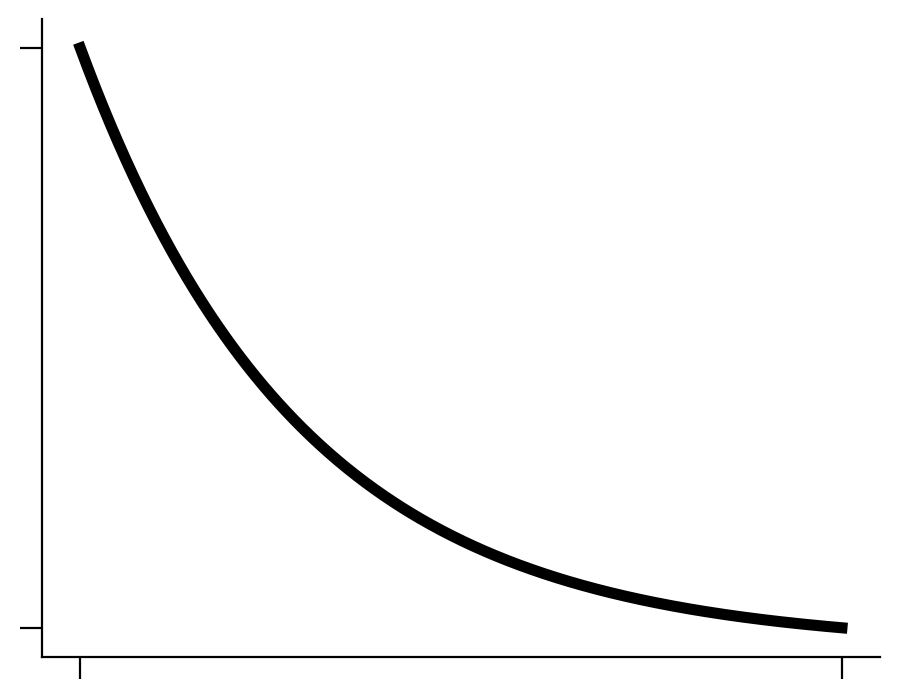

PosixPath('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/figures/figure2/fig2_x_vs_theta_hat.png')

In [8]:
fig, ax = plt.subplots(figsize=(4.6, 3.6))
fontsize = 16
ax.plot(theta_hat, 1-x_vals, color="black", linewidth=4.0)
#ax.set_xlabel(r"$\hat{\theta}$", fontsize=fontsize)
#ax.set_ylabel(r"$x$", fontsize=fontsize)
ax.set_xticks([-0.5 * np.pi, 0.5 * np.pi])
ax.set_xticklabels([])
ax.set_yticks([0, 1])
ax.set_yticklabels([])
#ax.set_xlim(float(theta_hat[0]), float(theta_hat[-1]))
#ax.set_ylim(0.0, float(model.boundary))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 设置x轴和y轴tick长度
ax.tick_params(axis='x', length=8)  # 你可以根据需要调整length数值
ax.tick_params(axis='y', length=8)  # 你可以根据需要调整length数值

fig.tight_layout()

output_path = REPO_ROOT / "figures" / "figure2" / "fig2_x_vs_theta_hat.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

output_path

np.float64(1.0)